## <span style="color:#2F749F;"><strong>📦 Sesión práctica 2: Análisis Univariado, bivariado y multivariado</strong></span>
---


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

In [1]:
nombre = "Nelson García"
correo = "nelson.garcia@udea.edu.co"
cedula = "060082"

print("Nombre:", nombre)
print("Correo", correo)
print("Cedula:", cedula)

Nombre: Nelson García
Correo nelson.garcia@udea.edu.co
Cedula: 060082


## <span style="color:black;"><strong>Parte 1: Análisis Univariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

A partir de una muestra simulada de ingresos, calcula la **media, mediana y moda**, y luego a interpretarlas.

1. Usa el número base `528310` (debes reemplazarlo con los últimos 6 dígitos de tu documento de identificación).  
2. Con este número genera una semilla (`np.random.seed`) para que los resultados sean reproducibles.  
3. Los ingresos se simulan con una distribución normal:  
   - Media teórica: `(base % 10) + 2`  
   - Desviación estándar: `2`  
   - Tamaño de muestra: `30`  
4. Los valores negativos se reemplazan por cero (pues los ingresos no pueden ser negativos).  
5. Grafica tus resultados (ver imagen de ejemplo)



Media: 3.96 mil pesos
Mediana: 4.00 mil pesos
Moda: 3.00 mil pesos
Arreglo: [3. 3. 7. 8. 5. 1. 1. 2. 6. 5. 4. 3. 3. 5. 7. 2. 5. 3. 4. 7. 5. 3. 4. 3.
 2. 7. 4. 4. 7. 3. 3. 4. 2. 3. 6. 3. 4. 5. 3. 6. 3. 5. 6. 3. 3. 3. 4. 4.
 4. 8. 9. 3. 2. 1. 4. 3. 0. 0. 4. 7. 1. 3. 2. 5. 4. 5. 4. 9. 4. 1. 4. 4.
 3. 5. 3. 4. 3. 1. 4. 2. 5. 0. 4. 2. 4. 2. 5. 5. 6. 2. 5. 5. 2. 9. 7. 2.
 2. 6. 5. 6.]


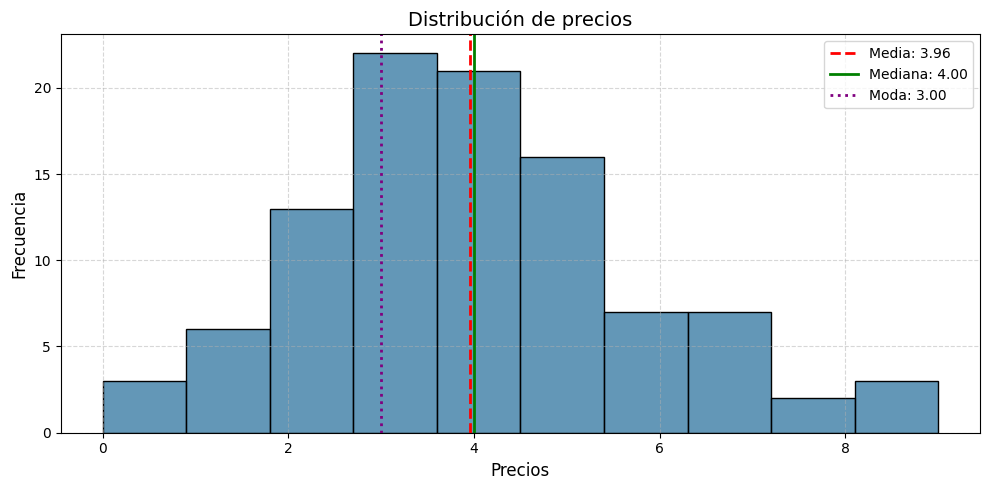

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

#semilla
base=60082
np.random.seed(base)

media=(base % 10)+2

# Precios mensuales simulados (en miles de pesos)
precio=np.random.normal(loc=media,scale=2,size=100).round(0)
# No considerar negativos 
precio =np.clip(precio,0,None)

# Cálculo de medidas
media = np.mean(precio)
mediana = np.median(precio)
moda = stats.mode(precio, keepdims=True).mode[0]

# Datos 
print(f"Media: {media:.2f} mil pesos")
print(f"Mediana: {mediana:.2f} mil pesos")
print(f"Moda: {moda:.2f} mil pesos")
print("Arreglo:", precio)

# Visualización
plt.figure(figsize=(10, 5))
sns.histplot(precio, bins=10, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

# Estética
plt.title("Distribución de precios", fontsize=14)
plt.xlabel("Precios", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>

La media y la mediana son muy similares lo cual indica que la distribución de los precios es bastante simétrica, y no está fuertemente sesgada hacia un lado.
La moda es más baja, con un valor de 3 mil pesos lo que muestra que hay cierta concentración de precios menores al promedio, aunque la mayoría se agrupa alrededor de 4 mil pesos.

La muestra de 100 precios simulada refleja unos precios centrados en 4 mil pesos, pero con una tendencia ligera hacia valores menores, lo cual puede interpretarse como la existencia de un segmento con salarios bajos dentro de la población.

En el histograma, se observa una concentración importante de salarios alrededor de 4 mil pesos, pero también una presencia significativa de valores pequeños, lo que genera que la moda este abajo de la media y la mediana.



### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)



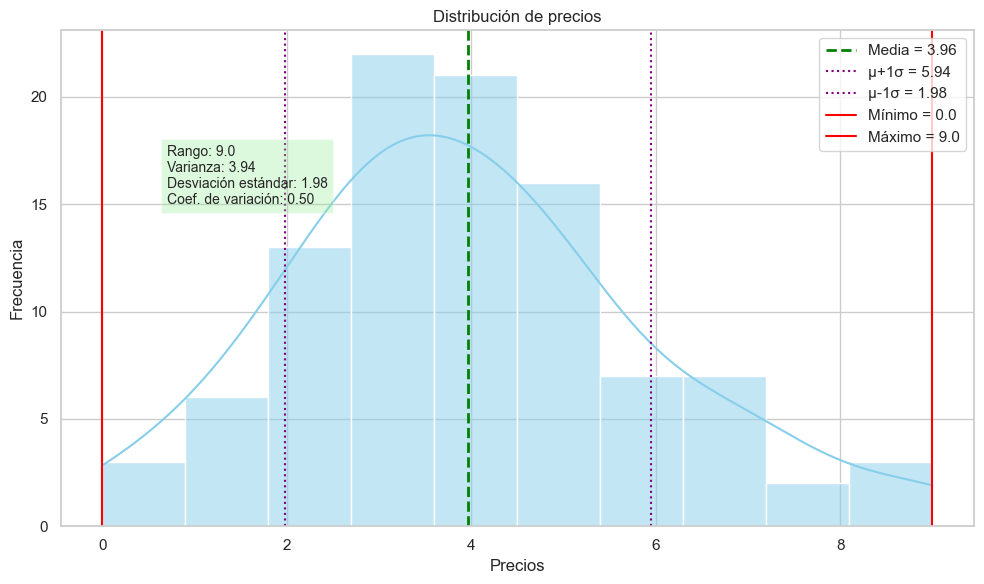

In [3]:
minimo = np.min(precio)
maximo = np.max(precio)
rango = maximo - minimo
varianza = np.var(precio, ddof=1)
desviacion = np.std(precio, ddof=1)
coef_var = desviacion / media

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(precio, bins=10, kde=True, color='skyblue')

# Líneas verticales
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='red', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

# Título y etiquetas
plt.title("Distribución de precios")
plt.xlabel("Precios")
plt.ylabel("Frecuencia")
plt.legend()

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
plt.text(0.7, 15, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()

### <span style="color:red;"><strong>Interpretación</strong></span>

- El rango muestra la amplitud total entre el precio más bajo y el más alto, en este caso entre 0 y 9.

- La Varianza mide la variabilidad global de los datos, los valores altos de la muestra simulada implica que los precios están más dispersos.

- La Desviación estándar indica cuánto, en promedio, se alejan los precios de la media. Para la simulación de 100 datos, en promedio, los precios se desvían ±1.98 mil pesos de la media (3.96).

- El Coeficiente de variación (CV) permite comparar la dispersión relativa; para un CV bajo (<20%) indica que los precios son bastante homogéneos respecto a la media. Para los datos simulados, este significa que la dispersión equivale a la mitad del valor promedio, lo que indica que los datos son moderadamente variables, no tan concentrados, pero tampoco totalmente dispersos.

### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal (ver la imagen de ejemplo)

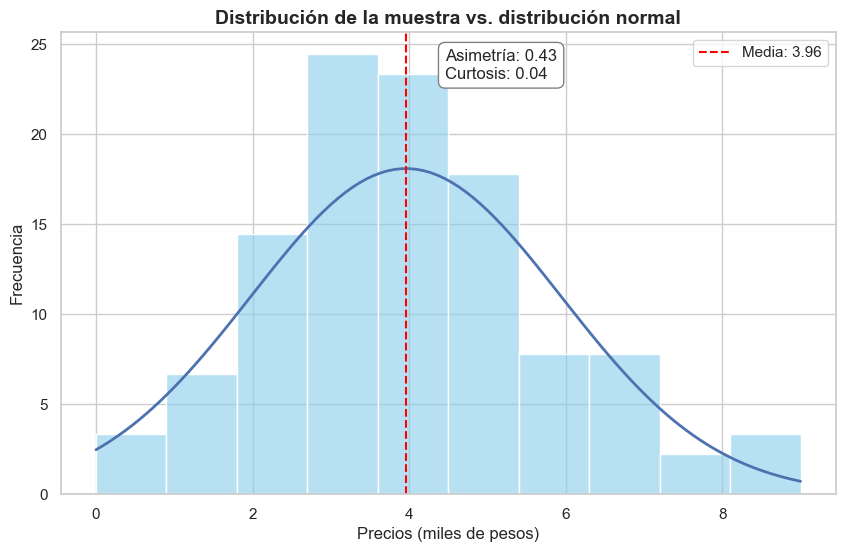

In [4]:
from scipy.stats import skew, kurtosis, norm

# Estilo visual
sns.set_theme(style="whitegrid")

# Cálculo de métricas
asimetria = skew(precio)
curtosis_valor = kurtosis(precio, fisher=True)

# Visualización con kde=false 
plt.figure(figsize=(10,6))
sns.histplot(precio, kde=False, color="skyblue", bins=10, stat="frequency", alpha=0.6)

# Curva normal con la media y la desviación de los datos generados
x = np.linspace(min(precio), max(precio), 100)
plt.plot(x, norm.pdf(x, media, desviacion) * len(precio) * (max(precio)-min(precio))/10,"b-", lw=2) 

# Línea en la media
plt.axvline(media, color="red", linestyle="--", label=f"Media: {media:.2f}")

# Anotaciones 
plt.text(media+0.5, max(plt.gca().get_ylim())*0.9,
         f"Asimetría: {asimetria:.2f}\nCurtosis: {curtosis_valor:.2f}",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray"))

# Títulos
plt.title("Distribución de la muestra vs. distribución normal", fontsize=14, fontweight="bold")
plt.xlabel("Precios (miles de pesos)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()



### <span style="color:red;"><strong>Interpretación</strong></span>

- La Asimetría tiene un valor de 0.43, al ser un valor positivo y cercano a cero, indica que la distribución presenta una ligera inclinación hacia la derecha. Esto significa que la mayoría de los valores se concentran alrededor de la media, pero existen algunos precios más altos que generan una pequeña cola extendida hacia los valores grandes. Sin embargo, al no superar 1, el sesgo es bajo y la distribución puede considerarse casi simétrica.

- La Curtosis tiene un valor de 0.04, valor que está muy próximo a 0, lo que implica que la distribución es mesocúrtica, es decir, tiene una distribución parecida a la de una distribución normal.


### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos (ver la imagen de ejemplo)




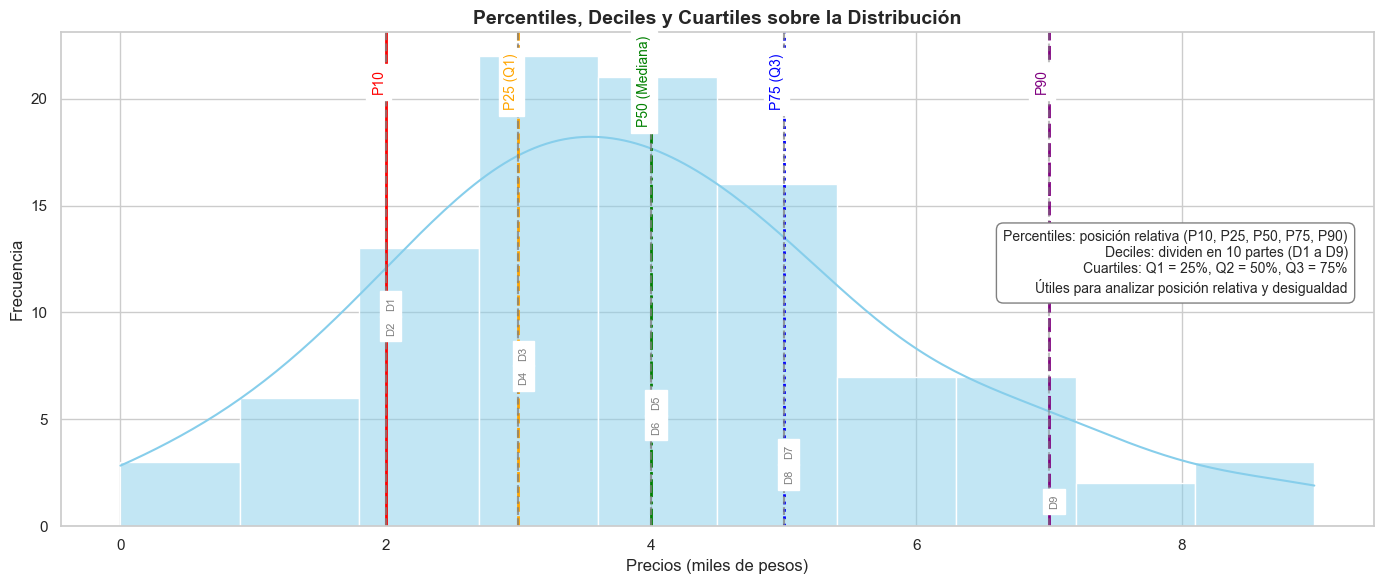

In [5]:
# Estilo visual
sns.set_theme(style="whitegrid")

# Cálculo de percentiles 
percentiles = {
    'P10': {'valor': np.percentile(precio, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(precio, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(precio, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(precio, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(precio, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(precio, i * 10) for i in range(1, 10)}

# Visualización
plt.figure(figsize=(14, 6))
sns.histplot(precio, kde=True, color='skyblue', bins=10)

# Líneas verticales para percentiles destacados
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'],
                linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.9, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             backgroundcolor='white')

# Líneas para deciles (D1 a D9)
for i, (etiqueta, valor) in enumerate(deciles.items(), start=1):
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.5)
    # Para que no se muestren encima uno de otro, muevo las etiquetas en diferentes alturas
    plt.text(valor, plt.ylim()[1]*(0.5 - i*0.05), etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='left',
             backgroundcolor='white')

# Recuadro 
texto = (
    "Percentiles: posición relativa (P10, P25, P50, P75, P90)\n"
    "Deciles: dividen en 10 partes (D1 a D9)\n"
    "Cuartiles: Q1 = 25%, Q2 = 50%, Q3 = 75%\n"
    "Útiles para analizar posición relativa y desigualdad"
    )
plt.text(0.98, 0.6, texto, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))

# Títulos y estilo
plt.title("Percentiles, Deciles y Cuartiles sobre la Distribución", fontsize=14, fontweight='bold')
plt.xlabel("Precios (miles de pesos)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


### <span style="color:red;"><strong>Interpretación</strong></span>


#### <span style="color:black;"><strong>Percetiles</strong></span>
- P10: El 10% de los precios está en 1 mil pesos o menos.
- P25 (Q1): El 25% de los precios está en 3 mil o menos.
- P50 (Mediana): La mitad de los precios está en 4 mil o menos, y la otra mitad en más de 4.
- P75 (Q3): El 75% de los precios está en 5 mil o menos.
- P90: El 90% de los precios está en 7 mil o menos; solo el 10% restante llega a 8 o 9.

Los datos de precios se concentran mayoritariamente entre 2 y 5, con unos pocos precios bajos (0–1) y algunos más altos (7–9). La distribución es bastante simétrica y no presenta colas extremas.





## <span style="color:black;"><strong>Parte 2: Análisis Bivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**. 
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  



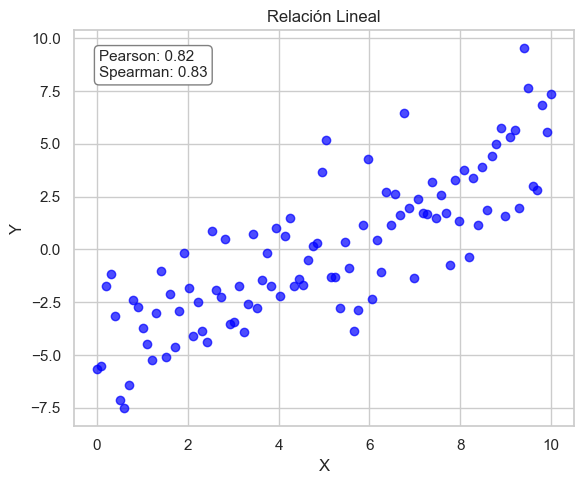

In [6]:
from scipy import stats

np.random.seed(60082)
n = 100

# Relación 
x = np.linspace(0, 10, n)
y = (x - 5) + np.random.normal(0, 2, n)

# Correlaciones
def calcular_correlaciones(x, y):
    pearson, _ = stats.pearsonr(x, y)
    spearman, _ = stats.spearmanr(x, y)
    return pearson, spearman

p1, s1 = calcular_correlaciones(x, y)

# Visualización comparativa
fig, ax = plt.subplots(figsize=(6, 5))

# Relación X1 vs Y1
ax.scatter(x, y, color="blue", alpha=0.7)
ax.set_title("Relación Lineal")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# Texto con coeficientes
texto = f"Pearson: {p1:.2f}\nSpearman: {s1:.2f}"
ax.text(0.05, 0.95, texto, transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.show()


### <span style="color:red;"><strong>Interpretación</strong></span>

- El coefiente Pearson tiene un valor de 0.82, lo que indica una correlación lineal fuerte y positiva entre x e y, es decir que cuando una variable aumenta, la otra también tiende a aumentar de forma bastante consistente y como es cercano a uno positivo, los puntos se agrupan de forma ascendente.

- El coefiente de Spearman tiene un valor 0.83, este mide la relación monótona entre las dos variables y también es fuerte y positiva, lo que confirma que no solo existe una relación lineal, sino también una relación monótona.

### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.



Tabla de contingencia:
Acceso a internet  No  Sí
Nivel educativo          
Básico              7  10
Medio               3  19
Superior            4  17

Resultados Chi-cuadrado:
Chi2 = 4.40, p-valor = 0.1109, grados de libertad = 2
Frecuencias esperadas:
 Acceso a internet        No         Sí
Nivel educativo                       
Básico             3.966667  13.033333
Medio              5.133333  16.866667
Superior           4.900000  16.100000 



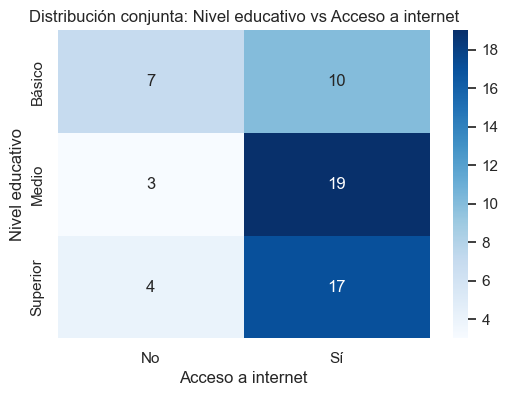

In [7]:
import pandas as pd
from scipy.stats import chi2_contingency

# Base de la cédula
base = 60082
np.random.seed(base)

# Muestra de 60 personas
n = 60

# Variables cualitativas 
niveles = ["Básico", "Medio", "Superior"]
internet = ["Sí", "No"]

nivel_educativo = np.random.choice(niveles, size=n, p=[0.3, 0.4, 0.3])   
acceso_internet = np.random.choice(internet, size=n, p=[0.7, 0.3])       

# DataFrame
df = pd.DataFrame({
    "Nivel educativo": nivel_educativo,
    "Acceso a internet": acceso_internet
})

# Tabla de contingencia
tabla = pd.crosstab(df["Nivel educativo"], df["Acceso a internet"])
print("Tabla de contingencia:")
print(tabla)

# Chi-cuadrado 
chi2, p, dof, esperados = chi2_contingency(tabla)
print("\nResultados Chi-cuadrado:")
print(f"Chi2 = {chi2:.2f}, p-valor = {p:.4f}, grados de libertad = {dof}")
print("Frecuencias esperadas:\n",pd.DataFrame(esperados, index=tabla.index, columns=tabla.columns), "\n")


# Visualización (mapa de calor)
plt.figure(figsize=(6,4))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
plt.title("Distribución conjunta: Nivel educativo vs Acceso a internet")
plt.show()


### <span style="color:red;"><strong>Interpretación</strong></span>

Partiendo de la hipótesis nula de que: El acceso a internet y el nivel educativo son independientes y la alternativa: Existe asociación entre el acceso a internet y el nivel educativo.
- p-valor = 0.1109, como es mayor que 0.05, no hay evidencia suficiente para rechazar la hipótesis nula; lo que, estadísticamente, no podemos afirmar que exista relación significativa entre el nivel educativo y el acceso a internet en esta muestra de 60 personas.
  
Diferencias entre mustras observadas y esperadas:
- En Básico sin internet: se esperaban 4, pero hubo 7, más de lo esperado.
- En Medio sin internet: se esperaban 5, pero hubo 3, menos de lo esperado.
- En Superior los valores observados y esperados están muy cerca.

